# 12 — AIA ResNet18 Physics-Safe Multi-Fold Hyperparameter Sensitivity

This notebook runs a **predefined, physics-safe hyperparameter sensitivity study** for the AIA image-only ResNet18 benchmark.

## Purpose

Notebook 11 showed that full-natural ResNet18 has useful skill in some years but weak stability across chronological folds. This notebook tests whether a small, controlled hyperparameter grid can improve robustness without using test years for model selection.

## Scientific protocol

- Folds: `test_2013`, `test_2014`, `test_2015`
- Label: `label_48h_final`
- No embedded NPZ labels
- No random flips, rotations, or crops
- Deterministic resize only
- Train-derived robust channel statistics per fold
- Threshold selected by validation max-TSS only
- Hyperparameter selection by **mean validation TSS across folds**
- Test metrics are reported for all configs but are not used to choose the config

## Default configs

The baseline is loaded from existing completed metrics and is not retrained by default. New configs trained by default:

1. `lower_lr`
2. `higher_dropout`
3. `reduced_pos_weight`

The notebook is resumable: completed config/fold JSON metrics are reused unless `RERUN_COMPLETED=True`.

In [1]:
from pathlib import Path
import json, hashlib, random, subprocess, time, gc, re
from dataclasses import dataclass, asdict
from typing import Dict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = str


def repo_root() -> Path:
    try:
        return Path(subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip())
    except Exception:
        return Path.cwd()

ROOT = repo_root()
METRICS_DIR = ROOT / "results" / "metrics"
MODELS_DIR = ROOT / "results" / "models"
FIG_DIR = ROOT / "results" / "figures"
LOG_DIR = ROOT / "logs"
for d in [METRICS_DIR, MODELS_DIR, FIG_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Repo root:", ROOT)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

Repo root: /home/abmoses2000/solar_flare_aia
Torch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA L4


In [2]:
@dataclass
class DataConfig:
    label_col: str = "label_48h_final"
    cache_dir: str = "cache/gcs_npz_alexnet_fold2015"
    image_size: int = 224
    in_channels: int = 6
    batch_size: int = 32
    num_workers: int = 2
    stats_max_images: int = 2000
    stats_pixels_per_channel_per_image: int = 512
    threshold_grid_step: float = 0.0025
    seed: int = 42

DCFG = DataConfig()
CACHE = ROOT / DCFG.cache_dir
CACHE.mkdir(parents=True, exist_ok=True)

FOLDS = [
    {"fold_id": "test_2013", "train_years": [2010, 2011], "val_years": [2012], "test_years": [2013]},
    {"fold_id": "test_2014", "train_years": [2010, 2011, 2012], "val_years": [2013], "test_years": [2014]},
    {"fold_id": "test_2015", "train_years": [2010, 2011, 2012, 2013], "val_years": [2014], "test_years": [2015]},
]

INCLUDE_BASELINE_FROM_EXISTING = True
RERUN_COMPLETED = False

TUNE_CONFIGS = [
    {"config_name": "lower_lr", "epochs": 6, "learning_rate": 3e-5, "weight_decay": 5e-4, "dropout": 0.30, "pos_weight_factor": 1.0},
    {"config_name": "higher_dropout", "epochs": 6, "learning_rate": 1e-4, "weight_decay": 5e-4, "dropout": 0.50, "pos_weight_factor": 1.0},
    {"config_name": "reduced_pos_weight", "epochs": 6, "learning_rate": 1e-4, "weight_decay": 5e-4, "dropout": 0.30, "pos_weight_factor": 0.5},
]

print(DCFG)
display(pd.DataFrame(TUNE_CONFIGS))

DataConfig(label_col='label_48h_final', cache_dir='cache/gcs_npz_alexnet_fold2015', image_size=224, in_channels=6, batch_size=32, num_workers=2, stats_max_images=2000, stats_pixels_per_channel_per_image=512, threshold_grid_step=0.0025, seed=42)


,config_name,epochs,learning_rate,weight_decay,dropout,pos_weight_factor
0,lower_lr,6,0.00003,0.0005,0.3,1.0
1,higher_dropout,6,0.00010,0.0005,0.5,1.0
2,reduced_pos_weight,6,0.00010,0.0005,0.3,0.5


In [3]:
def standardise_manifest_columns(df: pd.DataFrame, source_name: str) -> pd.DataFrame:
    df = df.copy()
    if "gcp_path" not in df.columns:
        for c in ["gcs_path", "npz_path", "file_path", "path"]:
            if c in df.columns:
                df["gcp_path"] = df[c]
                break
    if "gcp_path" not in df.columns:
        raise ValueError(f"{source_name} has no gcp_path-like column")
    if DCFG.label_col not in df.columns:
        raise ValueError(f"{source_name} has no {DCFG.label_col}")
    df[DCFG.label_col] = df[DCFG.label_col].astype(int)
    if "year" not in df.columns:
        if "timestamp" in df.columns:
            df["year"] = pd.to_datetime(df["timestamp"]).dt.year
        elif "date" in df.columns:
            df["year"] = pd.to_datetime(df["date"]).dt.year
        else:
            extracted = df["gcp_path"].astype(str).str.extract(r"/(20\d{2})/|_(20\d{2})\d{4}_")
            df["year"] = pd.to_numeric(extracted.bfill(axis=1).iloc[:, 0], errors="coerce").astype("Int64")
    df["year"] = df["year"].astype(int)
    return df


def load_sample_universe() -> pd.DataFrame:
    triplets = [
        (
            ROOT / "results/metrics/aia_resnet18_physics_safe_fold2015_fullnatural_benchmark_fullnatural_train_samples.csv",
            ROOT / "results/metrics/aia_resnet18_physics_safe_fold2015_fullnatural_benchmark_fullnatural_val_samples.csv",
            ROOT / "results/metrics/aia_resnet18_physics_safe_fold2015_fullnatural_benchmark_fullnatural_test_samples.csv",
        ),
        (
            ROOT / "local_archive/aborted_06_full_attempt/aia_alexnet_fold2015_benchmark_full_train_samples.csv",
            ROOT / "local_archive/aborted_06_full_attempt/aia_alexnet_fold2015_benchmark_full_val_samples.csv",
            ROOT / "local_archive/aborted_06_full_attempt/aia_alexnet_fold2015_benchmark_full_test_samples.csv",
        ),
        (
            ROOT / "results/metrics/aia_alexnet_fold2015_benchmark_full_train_samples.csv",
            ROOT / "results/metrics/aia_alexnet_fold2015_benchmark_full_val_samples.csv",
            ROOT / "results/metrics/aia_alexnet_fold2015_benchmark_full_test_samples.csv",
        ),
    ]
    frames, used = [], []
    for triplet in triplets:
        if all(p.exists() for p in triplet):
            for p in triplet:
                frames.append(standardise_manifest_columns(pd.read_csv(p), str(p)))
                used.append(str(p.relative_to(ROOT)))
            break
    if not frames:
        raise FileNotFoundError("Could not find full-natural sample CSV triplet.")
    df = pd.concat(frames, ignore_index=True).drop_duplicates(subset=["gcp_path"]).reset_index(drop=True)
    print("Loaded sample files:")
    for u in used:
        print(" -", u)
    return df

universe = load_sample_universe()
year_summary = universe.groupby("year")[DCFG.label_col].agg(rows="count", positives="sum").reset_index()
year_summary["negatives"] = year_summary["rows"] - year_summary["positives"]
year_summary["positive_rate"] = year_summary["positives"] / year_summary["rows"]
display(year_summary)

Loaded sample files:
 - results/metrics/aia_resnet18_physics_safe_fold2015_fullnatural_benchmark_fullnatural_train_samples.csv
 - results/metrics/aia_resnet18_physics_safe_fold2015_fullnatural_benchmark_fullnatural_val_samples.csv
 - results/metrics/aia_resnet18_physics_safe_fold2015_fullnatural_benchmark_fullnatural_test_samples.csv


,year,rows,positives,negatives,positive_rate
0,2010,3306,29,3277,0.008772
1,2011,11142,404,10738,0.036259
2,2012,10815,305,10510,0.028202
3,2013,13066,492,12574,0.037655
4,2014,11627,629,10998,0.054098
5,2015,11236,531,10705,0.047259


In [4]:
def local_path_for_gcs(gcp_path: str) -> Path:
    return CACHE / (hashlib.md5(gcp_path.encode("utf-8")).hexdigest() + "_" + Path(gcp_path).name)


def build_fold_splits(fold):
    train = universe[universe["year"].isin(fold["train_years"])].copy()
    val = universe[universe["year"].isin(fold["val_years"])].copy()
    test = universe[universe["year"].isin(fold["test_years"])].copy()
    train["split"], val["split"], test["split"] = "train", "val", "test"
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

fold_summaries, all_required = [], set()
for fold in FOLDS:
    train_df, val_df, test_df = build_fold_splits(fold)
    for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        rows = len(df)
        pos = int(df[DCFG.label_col].sum())
        assert rows > 0 and pos > 0, (fold["fold_id"], split_name, rows, pos)
        fold_summaries.append({
            "fold_id": fold["fold_id"], "split": split_name,
            "years": str(sorted(df["year"].unique().tolist())),
            "rows": rows, "positives": pos, "negatives": rows - pos,
            "positive_rate": pos / rows,
        })
        all_required.update(df["gcp_path"].astype(str).tolist())

missing = [p for p in sorted(all_required) if not local_path_for_gcs(p).exists()]
missing_path = METRICS_DIR / "aia_resnet18_hp_sensitivity_multifold_missing_gcs_paths.txt"
missing_path.write_text("\n".join(missing) + ("\n" if missing else ""))

display(pd.DataFrame(fold_summaries))
print("required_unique:", len(all_required))
print("cached:", len(all_required) - len(missing))
print("missing:", len(missing))
if missing:
    print("first_missing:", missing[:5])
    raise RuntimeError(f"Cache incomplete: missing {len(missing)} files.")

,fold_id,split,years,rows,positives,negatives,positive_rate
0,test_2013,train,"[2010, 2011]",14448,433,14015,0.029970
1,test_2013,val,[2012],10815,305,10510,0.028202
2,test_2013,test,[2013],13066,492,12574,0.037655
3,test_2014,train,"[2010, 2011, 2012]",25263,738,24525,0.029213
4,test_2014,val,[2013],13066,492,12574,0.037655
5,test_2014,test,[2014],11627,629,10998,0.054098
6,test_2015,train,"[2010, 2011, 2012, 2013]",38329,1230,37099,0.032091
7,test_2015,val,[2014],11627,629,10998,0.054098
8,test_2015,test,[2015],11236,531,10705,0.047259


required_unique: 61192
cached: 61192
missing: 0


In [5]:
def pick_npz_array(npz) -> np.ndarray:
    for k in ["x", "X", "image", "images", "data", "arr_0"]:
        if k in npz.files:
            arr = npz[k]
            if isinstance(arr, np.ndarray) and arr.ndim >= 2:
                return arr
    for k in npz.files:
        arr = npz[k]
        if isinstance(arr, np.ndarray) and arr.ndim >= 2:
            return arr
    raise ValueError(f"No image-like array in keys={npz.files}")


def to_chw_six(arr: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr)
    if arr.ndim == 4:
        arr = np.squeeze(arr)
    if arr.ndim != 3:
        raise ValueError(f"Expected 3D AIA array, got {arr.shape}")
    if arr.shape[0] == DCFG.in_channels:
        return arr.astype(np.float32)
    if arr.shape[-1] == DCFG.in_channels:
        return np.transpose(arr, (2, 0, 1)).astype(np.float32)
    raise ValueError(f"Cannot infer six-channel layout from shape={arr.shape}")


def load_raw_chw(gcp_path: str) -> np.ndarray:
    with np.load(local_path_for_gcs(gcp_path), allow_pickle=False) as npz:
        arr = pick_npz_array(npz)
    x = to_chw_six(arr)
    return np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


def deterministic_pixel_sample(channel_2d: np.ndarray, n: int, seed_key: str) -> np.ndarray:
    flat = channel_2d.reshape(-1)
    if flat.size <= n:
        return flat.astype(np.float32)
    h = int(hashlib.md5(seed_key.encode("utf-8")).hexdigest()[:8], 16)
    rng = np.random.default_rng(h)
    idx = rng.choice(flat.size, size=n, replace=False)
    return flat[idx].astype(np.float32)


def compute_train_channel_stats(train_df, fold_id: str, progress_log: Path) -> Dict:
    stats_path = METRICS_DIR / f"aia_resnet18_hp_sensitivity_{fold_id}_train_channel_stats.json"
    if stats_path.exists():
        return json.loads(stats_path.read_text())
    train_paths = train_df["gcp_path"].drop_duplicates().tolist()[:DCFG.stats_max_images]
    samples_by_channel = [[] for _ in range(DCFG.in_channels)]
    t0 = time.time()
    for i, gcp_path in enumerate(train_paths, 1):
        chw = load_raw_chw(gcp_path)
        for c in range(DCFG.in_channels):
            vals = deterministic_pixel_sample(chw[c], DCFG.stats_pixels_per_channel_per_image, f"hp|{fold_id}|{gcp_path}|{c}")
            samples_by_channel[c].append(vals)
        if i % 100 == 0 or i == len(train_paths):
            msg = f"stats fold={fold_id} progress: {i}/{len(train_paths)} images elapsed_min={(time.time()-t0)/60:.1f}"
            print(msg, flush=True)
            with open(progress_log, "a") as fh:
                fh.write(msg + "\n")
    channel_stats = []
    for c in range(DCFG.in_channels):
        vals = np.concatenate(samples_by_channel[c]).astype(np.float32)
        vals = vals[np.isfinite(vals)]
        q01, q25, q50, q75, q99 = np.percentile(vals, [1, 25, 50, 75, 99])
        scale = float(q75 - q25)
        if not np.isfinite(scale) or scale <= 1e-6:
            scale = float(np.std(vals) + 1e-6)
        channel_stats.append({
            "channel_index": c, "q01": float(q01), "q25": float(q25), "median": float(q50),
            "q75": float(q75), "q99": float(q99), "iqr_or_std": scale, "sample_count": int(vals.size)
        })
    payload = {
        "normalisation": "train_derived_channel_robust_q01_q99_clip_median_iqr_scale",
        "source_split": "train_only", "fold_id": fold_id,
        "stats_max_images": DCFG.stats_max_images,
        "stats_pixels_per_channel_per_image": DCFG.stats_pixels_per_channel_per_image,
        "channel_stats": channel_stats,
    }
    stats_path.write_text(json.dumps(payload, indent=2))
    return payload

In [6]:
class AIANPZPhysicsSafeDataset(Dataset):
    def __init__(self, df: pd.DataFrame, stats_payload: Dict):
        self.df = df.reset_index(drop=True)
        stats = stats_payload["channel_stats"]
        self.clip_lo = np.array([s["q01"] for s in stats], dtype=np.float32)[:, None, None]
        self.clip_hi = np.array([s["q99"] for s in stats], dtype=np.float32)[:, None, None]
        self.median = np.array([s["median"] for s in stats], dtype=np.float32)[:, None, None]
        scale = np.array([s["iqr_or_std"] for s in stats], dtype=np.float32)[:, None, None]
        self.scale = np.where(np.abs(scale) < 1e-6, 1.0, scale).astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        gcp_path = row["gcp_path"]
        y = np.float32(row[DCFG.label_col])
        x = load_raw_chw(gcp_path)
        x = np.clip(x, self.clip_lo, self.clip_hi)
        x = (x - self.median) / self.scale
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        x = torch.from_numpy(x)
        if x.shape[-2:] != (DCFG.image_size, DCFG.image_size):
            x = F.interpolate(x.unsqueeze(0), size=(DCFG.image_size, DCFG.image_size), mode="bilinear", align_corners=False).squeeze(0)
        return x, torch.tensor(y, dtype=torch.float32), gcp_path

class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.dropout = nn.Dropout2d(dropout) if dropout and dropout > 0 else nn.Identity()
        self.shortcut = nn.Identity()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(nn.Conv2d(in_planes, planes, 1, stride, bias=False), nn.BatchNorm2d(planes))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out, inplace=True)

class ResNet18AIA(nn.Module):
    def __init__(self, in_channels=6, dropout=0.30):
        super().__init__()
        self.in_planes = 64
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, 7, 2, 3, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(3, 2, 1)
        )
        self.layer1 = self._make_layer(64, 2, 1, dropout/2)
        self.layer2 = self._make_layer(128, 2, 2, dropout/2)
        self.layer3 = self._make_layer(256, 2, 2, dropout/2)
        self.layer4 = self._make_layer(512, 2, 2, dropout/2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(512, 1)
    def _make_layer(self, planes, blocks, stride, dropout):
        layers = [BasicBlock(self.in_planes, planes, stride, dropout)]
        self.in_planes = planes
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_planes, planes, 1, dropout))
        return nn.Sequential(*layers)
    def forward(self, x):
        x = self.stem(x); x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.avgpool(x); x = torch.flatten(x, 1); x = self.dropout(x)
        return self.fc(x).squeeze(1)

In [7]:
def safe_auc(y_true, y_prob, kind="roc"):
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_prob)) if kind == "roc" else float(average_precision_score(y_true, y_prob))


def confusion_at_threshold(y_true, y_prob, thr):
    y_true = np.asarray(y_true).astype(int); y_pred = (np.asarray(y_prob) >= thr).astype(int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum()); tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum()); fn = int(((y_true == 1) & (y_pred == 0)).sum())
    recall = tp/(tp+fn) if (tp+fn) else 0.0; specificity = tn/(tn+fp) if (tn+fp) else 0.0
    precision = tp/(tp+fp) if (tp+fp) else 0.0; accuracy = (tp+tn)/max(tp+tn+fp+fn, 1)
    f1 = 2*precision*recall/(precision+recall) if (precision+recall) else 0.0
    tss = recall + specificity - 1.0
    total = tp+tn+fp+fn
    pe = ((tp+fp)*(tp+fn)+(fn+tn)*(fp+tn))/(total*total) if total else 0.0
    hss = (accuracy-pe)/(1-pe) if abs(1-pe) > 1e-12 else 0.0
    return {"threshold": float(thr), "accuracy": float(accuracy), "precision": float(precision), "recall": float(recall),
            "specificity": float(specificity), "f1": float(f1), "tss": float(tss), "hss": float(hss),
            "tp": tp, "tn": tn, "fp": fp, "fn": fn}


def threshold_grid_metrics(y_true, y_prob):
    thresholds = np.arange(0.0, 1.0 + DCFG.threshold_grid_step, DCFG.threshold_grid_step)
    rows = [confusion_at_threshold(y_true, y_prob, thr) for thr in thresholds]
    grid = pd.DataFrame(rows)
    best = grid.sort_values(["tss", "hss", "threshold"], ascending=[False, False, True]).iloc[0].to_dict()
    return grid, best

@torch.no_grad()
def predict(model, loader, split_name, progress_log):
    model.eval(); y_true=[]; y_prob=[]; paths=[]; t0=time.time()
    for batch_idx, (xb, yb, batch_paths) in enumerate(loader, 1):
        xb = xb.to(device, non_blocking=True)
        prob = torch.sigmoid(model(xb)).detach().cpu().numpy()
        y_prob.extend(prob.tolist()); y_true.extend(yb.numpy().astype(int).tolist()); paths.extend(list(batch_paths))
        if batch_idx % 100 == 0 or batch_idx == len(loader):
            msg = f"predict split={split_name} batch={batch_idx}/{len(loader)} elapsed_min={(time.time()-t0)/60:.1f}"
            print(msg, flush=True)
            with open(progress_log, "a") as fh: fh.write(msg + "\n")
    return pd.DataFrame({"gcp_path": paths, "y_true": y_true, "y_prob": y_prob})


def evaluate_split(model, loader, split_name, progress_log):
    pred = predict(model, loader, split_name, progress_log)
    y_true = pred["y_true"].values; y_prob = pred["y_prob"].values
    grid, best = threshold_grid_metrics(y_true, y_prob)
    return {"roc_auc": safe_auc(y_true, y_prob, "roc"), "pr_auc": safe_auc(y_true, y_prob, "pr"),
            "brier_score": float(brier_score_loss(y_true, y_prob)), "at_0_5": confusion_at_threshold(y_true, y_prob, 0.5),
            "best_tss": best}, grid, pred


def summarise_split(df, split):
    rows = int(len(df)); pos = int(df[DCFG.label_col].sum())
    return {"split": split, "rows": rows, "positives": pos, "negatives": rows-pos, "positive_rate": pos/rows,
            "years": str(sorted(df["year"].unique().tolist()))}

In [8]:
def baseline_metric_path(fold_id: str):
    mapping = {
        "test_2013": METRICS_DIR / "aia_resnet18_physics_safe_multifold_fullnatural_test_2013_metrics.json",
        "test_2014": METRICS_DIR / "aia_resnet18_physics_safe_multifold_fullnatural_test_2014_metrics.json",
        "test_2015": METRICS_DIR / "aia_resnet18_physics_safe_fold2015_fullnatural_benchmark_fullnatural_physics_safe_metrics.json",
    }
    p = mapping.get(fold_id)
    return p if p is not None and p.exists() else None


def extract_summary_row(metrics_path: Path, config_name: str, source_kind: str):
    m = json.loads(metrics_path.read_text())
    test = m.get("test", {}).get("at_selected_threshold", {}) or {}
    val_best = m.get("validation", {}).get("best_tss", {}) or {}
    data_summary = m.get("data_summary", [])
    def split_value(split, key):
        for r in data_summary:
            if str(r.get("split", "")).lower() == split:
                return r.get(key, np.nan)
        return np.nan
    return {
        "config_name": config_name, "source_kind": source_kind, "fold_id": m.get("fold_id", metrics_path.stem),
        "metrics_file": str(metrics_path.relative_to(ROOT)), "train_rows": split_value("train", "rows"),
        "val_rows": split_value("val", "rows"), "test_rows": split_value("test", "rows"),
        "test_positives": split_value("test", "positives"), "test_negatives": split_value("test", "negatives"),
        "best_epoch": m.get("best_epoch", np.nan), "selected_threshold": m.get("selected_threshold_from_validation", test.get("threshold", np.nan)),
        "val_roc_auc": m.get("validation", {}).get("roc_auc", np.nan), "val_pr_auc": m.get("validation", {}).get("pr_auc", np.nan),
        "val_tss": val_best.get("tss", np.nan), "val_hss": val_best.get("hss", np.nan),
        "test_roc_auc": m.get("test", {}).get("roc_auc", np.nan), "test_pr_auc": m.get("test", {}).get("pr_auc", np.nan),
        "test_brier_score": m.get("test", {}).get("brier_score", np.nan), "test_accuracy": test.get("accuracy", np.nan),
        "test_precision": test.get("precision", np.nan), "test_recall": test.get("recall", np.nan),
        "test_specificity": test.get("specificity", np.nan), "test_f1": test.get("f1", np.nan),
        "test_tss": test.get("tss", np.nan), "test_hss": test.get("hss", np.nan),
        "test_tp": test.get("tp", np.nan), "test_tn": test.get("tn", np.nan), "test_fp": test.get("fp", np.nan), "test_fn": test.get("fn", np.nan),
        "diagnostic_test_best_tss": m.get("test", {}).get("best_tss", {}).get("tss", np.nan),
    }

baseline_rows = []
if INCLUDE_BASELINE_FROM_EXISTING:
    for fold in FOLDS:
        p = baseline_metric_path(fold["fold_id"])
        if p is None:
            raise FileNotFoundError(f"Missing baseline metrics for {fold['fold_id']}. Run Notebook 11 first.")
        baseline_rows.append(extract_summary_row(p, "baseline_existing", "existing_baseline"))
    display(pd.DataFrame(baseline_rows))

,config_name,source_kind,fold_id,metrics_file,train_rows,val_rows,test_rows,test_positives,test_negatives,best_epoch,...,test_recall,test_specificity,test_f1,test_tss,test_hss,test_tp,test_tn,test_fp,test_fn,diagnostic_test_best_tss
0,baseline_existing,existing_baseline,test_2013,results/metrics/aia_resnet18_physics_safe_mult...,14448,10815,13066,492,12574,1,...,0.737805,0.502386,0.102081,0.240191,0.034392,363,6317,6257,129,0.253846
1,baseline_existing,existing_baseline,test_2014,results/metrics/aia_resnet18_physics_safe_mult...,25263,13066,11627,629,10998,3,...,0.384738,0.623386,0.096549,0.008124,0.002130,242,6856,4142,387,0.009247
2,baseline_existing,existing_baseline,test_2015,results/metrics/aia_resnet18_physics_safe_fold...,38329,11627,11236,531,10705,1,...,0.868173,0.585241,0.169735,0.453414,0.092331,461,6265,4440,70,0.456011


In [9]:
def safe_config_name(name: str) -> str:
    return re.sub(r"[^A-Za-z0-9_\-]+", "_", name)


def make_loaders(train_df, val_df, test_df, stats_payload):
    train_ds = AIANPZPhysicsSafeDataset(train_df, stats_payload)
    val_ds = AIANPZPhysicsSafeDataset(val_df, stats_payload)
    test_ds = AIANPZPhysicsSafeDataset(test_df, stats_payload)
    common = dict(num_workers=DCFG.num_workers, pin_memory=torch.cuda.is_available(), persistent_workers=DCFG.num_workers > 0)
    return (
        DataLoader(train_ds, batch_size=DCFG.batch_size, shuffle=True, **common),
        DataLoader(val_ds, batch_size=DCFG.batch_size, shuffle=False, **common),
        DataLoader(test_ds, batch_size=DCFG.batch_size, shuffle=False, **common),
    )


def train_one_config_fold(config: Dict, fold: Dict):
    config_name = safe_config_name(config["config_name"]); fold_id = fold["fold_id"]
    run_prefix = f"aia_resnet18_hp_sensitivity_{config_name}_{fold_id}"
    metrics_path = METRICS_DIR / f"{run_prefix}_metrics.json"
    if metrics_path.exists() and not RERUN_COMPLETED:
        print(f"Reusing completed metrics: {metrics_path.relative_to(ROOT)}")
        return metrics_path

    progress_log = METRICS_DIR / f"{run_prefix}_progress.log"
    progress_log.write_text("")
    def log(msg):
        print(msg, flush=True)
        with open(progress_log, "a") as fh: fh.write(msg + "\n")

    seed_everything(DCFG.seed)
    train_df, val_df, test_df = build_fold_splits(fold)
    train_sample_path = METRICS_DIR / f"{run_prefix}_train_samples.csv"; train_df.to_csv(train_sample_path, index=False)
    val_sample_path = METRICS_DIR / f"{run_prefix}_val_samples.csv"; val_df.to_csv(val_sample_path, index=False)
    test_sample_path = METRICS_DIR / f"{run_prefix}_test_samples.csv"; test_df.to_csv(test_sample_path, index=False)
    data_summary = [summarise_split(train_df, "train"), summarise_split(val_df, "val"), summarise_split(test_df, "test")]

    log(f"===== START CONFIG={config_name} FOLD={fold_id} =====")
    log(json.dumps({"config": config, "data_summary": data_summary}, indent=2))

    stats_payload = compute_train_channel_stats(train_df, fold_id, progress_log)
    train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df, stats_payload)

    pos = float(train_df[DCFG.label_col].sum()); neg = float(len(train_df) - pos)
    raw_pos_weight = neg / max(pos, 1.0)
    pos_weight_value = raw_pos_weight * float(config["pos_weight_factor"])
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)

    model = ResNet18AIA(in_channels=DCFG.in_channels, dropout=float(config["dropout"])).to(device)
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=float(config["learning_rate"]), weight_decay=float(config["weight_decay"]))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    model_path = MODELS_DIR / f"{run_prefix}.pt"
    history_path = METRICS_DIR / f"{run_prefix}_history.csv"
    interim_path = METRICS_DIR / f"{run_prefix}_interim_metrics.json"
    history = []; best_val_tss = -999.0; best_epoch = None

    for epoch in range(1, int(config["epochs"]) + 1):
        model.train(); total_loss = 0.0; n = 0; t0 = time.time()
        for batch_idx, (xb, yb, _) in enumerate(train_loader, 1):
            xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb); loss = criterion(logits, yb); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            bs = xb.size(0); total_loss += float(loss.detach().cpu()) * bs; n += bs
            if batch_idx % 100 == 0 or batch_idx == len(train_loader):
                log(f"config={config_name} fold={fold_id} epoch={epoch:02d} batch={batch_idx}/{len(train_loader)} loss_running={total_loss/max(n,1):.4f} elapsed_min={(time.time()-t0)/60:.1f}")
        train_loss = total_loss / max(n, 1)
        val_metrics, _, _ = evaluate_split(model, val_loader, "val", progress_log)
        val_best = val_metrics["best_tss"]; val_tss = float(val_best["tss"]); lr_now = float(optimizer.param_groups[0]["lr"])
        row = {"config_name": config_name, "fold_id": fold_id, "epoch": epoch, "train_loss": train_loss,
               "val_roc_auc": val_metrics["roc_auc"], "val_pr_auc": val_metrics["pr_auc"],
               "val_best_threshold": val_best["threshold"], "val_tss": val_tss, "val_hss": float(val_best["hss"]), "lr": lr_now}
        history.append(row); pd.DataFrame(history).to_csv(history_path, index=False)
        interim_path.write_text(json.dumps({"completed_epochs": epoch, "latest_epoch": row, "best_epoch_so_far": best_epoch, "best_val_tss_so_far": best_val_tss, "history": history}, indent=2))
        log(f"config={config_name} fold={fold_id} epoch={epoch:02d}/{config['epochs']} COMPLETE loss={train_loss:.4f} val_auc={val_metrics['roc_auc']:.4f} val_pr={val_metrics['pr_auc']:.4f} val_thr={val_best['threshold']:.4f} val_tss={val_tss:.4f} val_hss={val_best['hss']:.4f} lr={lr_now:.2e}")
        scheduler.step(val_tss)
        if val_tss > best_val_tss:
            best_val_tss = val_tss; best_epoch = epoch
            torch.save({"model_state_dict": model.state_dict(), "data_config": asdict(DCFG), "tune_config": config,
                        "fold": fold, "best_epoch": best_epoch, "best_val_tss": best_val_tss,
                        "trainable_parameters": trainable_params, "channel_stats": stats_payload}, model_path)
            log(f"saved checkpoint -> {model_path}")

    log(f"Training complete config={config_name} fold={fold_id}. Best epoch={best_epoch}, best_val_tss={best_val_tss}")
    ckpt = torch.load(model_path, map_location=device); model.load_state_dict(ckpt["model_state_dict"]); model.to(device)
    val_metrics, val_grid, val_pred = evaluate_split(model, val_loader, "val_final", progress_log)
    test_metrics_raw, test_grid, test_pred = evaluate_split(model, test_loader, "test_final", progress_log)
    selected_threshold = float(val_metrics["best_tss"]["threshold"])
    test_at_selected = confusion_at_threshold(test_pred["y_true"].values, test_pred["y_prob"].values, selected_threshold)

    val_pred_path = METRICS_DIR / f"{run_prefix}_val_predictions.csv"; val_pred.to_csv(val_pred_path, index=False)
    test_pred_path = METRICS_DIR / f"{run_prefix}_test_predictions.csv"; test_pred.to_csv(test_pred_path, index=False)
    val_grid_path = METRICS_DIR / f"{run_prefix}_val_threshold_grid.csv"; val_grid.to_csv(val_grid_path, index=False)
    test_grid_path = METRICS_DIR / f"{run_prefix}_test_threshold_grid.csv"; test_grid.to_csv(test_grid_path, index=False)

    metrics = {
        "experiment_name": "aia_resnet18_physics_safe_multifold_hyperparameter_sensitivity",
        "config_name": config_name, "tune_config": config, "fold_id": fold_id, "fold": fold,
        "data_summary": data_summary,
        "physics_safety": {"label_source": DCFG.label_col, "uses_embedded_npz_label": False, "spatial_augmentation": False,
                           "random_flip": False, "random_rotation": False, "random_crop": False,
                           "normalisation": stats_payload["normalisation"], "normalisation_source": "training split only per fold",
                           "weighted_random_sampler": False, "threshold_protocol": "validation max-TSS applied unchanged to test",
                           "selection_protocol": "select config by mean validation TSS across folds"},
        "model": {"architecture": "ResNet18 six-channel AIA CNN", "trainable_parameters": trainable_params,
                  "image_size": DCFG.image_size, "batch_size": DCFG.batch_size, "epochs": int(config["epochs"]),
                  "learning_rate": float(config["learning_rate"]), "weight_decay": float(config["weight_decay"]),
                  "dropout": float(config["dropout"]), "raw_pos_weight": raw_pos_weight,
                  "pos_weight_factor": float(config["pos_weight_factor"]), "effective_pos_weight": pos_weight_value},
        "best_epoch": int(ckpt["best_epoch"]), "selected_threshold_from_validation": selected_threshold,
        "validation": val_metrics,
        "test": {"roc_auc": test_metrics_raw["roc_auc"], "pr_auc": test_metrics_raw["pr_auc"], "brier_score": test_metrics_raw["brier_score"],
                 "at_0_5": test_metrics_raw["at_0_5"], "best_tss": test_metrics_raw["best_tss"], "at_selected_threshold": test_at_selected},
        "artifacts": {"model_path": str(model_path.relative_to(ROOT)), "metrics_path": str(metrics_path.relative_to(ROOT)),
                      "history_path": str(history_path.relative_to(ROOT)), "progress_log": str(progress_log.relative_to(ROOT)),
                      "train_samples": str(train_sample_path.relative_to(ROOT)), "val_samples": str(val_sample_path.relative_to(ROOT)),
                      "test_samples": str(test_sample_path.relative_to(ROOT))},
    }
    metrics_path.write_text(json.dumps(metrics, indent=2)); log(f"Metrics saved: {metrics_path}")
    del model, train_loader, val_loader, test_loader
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return metrics_path

In [10]:
metric_paths = []
if INCLUDE_BASELINE_FROM_EXISTING:
    for row in baseline_rows:
        metric_paths.append(Path(row["metrics_file"]))

for config in TUNE_CONFIGS:
    for fold in FOLDS:
        metric_paths.append(train_one_config_fold(config, fold))

print("Metric files collected:")
for p in metric_paths:
    print("-", p)

Reusing completed metrics: results/metrics/aia_resnet18_hp_sensitivity_lower_lr_test_2013_metrics.json
Reusing completed metrics: results/metrics/aia_resnet18_hp_sensitivity_lower_lr_test_2014_metrics.json
Reusing completed metrics: results/metrics/aia_resnet18_hp_sensitivity_lower_lr_test_2015_metrics.json
Reusing completed metrics: results/metrics/aia_resnet18_hp_sensitivity_higher_dropout_test_2013_metrics.json
Reusing completed metrics: results/metrics/aia_resnet18_hp_sensitivity_higher_dropout_test_2014_metrics.json


===== START CONFIG=higher_dropout FOLD=test_2015 =====


{
  "config": {
    "config_name": "higher_dropout",
    "epochs": 6,
    "learning_rate": 0.0001,
    "weight_decay": 0.0005,
    "dropout": 0.5,
    "pos_weight_factor": 1.0
  },
  "data_summary": [
    {
      "split": "train",
      "rows": 38329,
      "positives": 1230,
      "negatives": 37099,
      "positive_rate": 0.03209058415299121,
      "years": "[2010, 2011, 2012, 2013]"
    },
    {
      "split": "val",
      "rows": 11627,
      "positives": 629,
      "negatives": 10998,
      "positive_rate": 0.05409821966113357,
      "years": "[2014]"
    },
    {
      "split": "test",
      "rows": 11236,
      "positives": 531,
      "negatives": 10705,
      "positive_rate": 0.04725881096475614,
      "years": "[2015]"
    }
  ]
}


config=higher_dropout fold=test_2015 epoch=01 batch=100/1198 loss_running=1.8568 elapsed_min=2.2


config=higher_dropout fold=test_2015 epoch=01 batch=200/1198 loss_running=1.6567 elapsed_min=4.4


...

predict split=test_final batch=200/352 elapsed_min=4.2


predict split=test_final batch=300/352 elapsed_min=6.4


predict split=test_final batch=352/352 elapsed_min=7.5


Metrics saved: /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_hp_sensitivity_reduced_pos_weight_test_2015_metrics.json


Metric files collected:
- results/metrics/aia_resnet18_physics_safe_multifold_fullnatural_test_2013_metrics.json
- results/metrics/aia_resnet18_physics_safe_multifold_fullnatural_test_2014_metrics.json
- results/metrics/aia_resnet18_physics_safe_fold2015_fullnatural_benchmark_fullnatural_physics_safe_metrics.json
- /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_hp_sensitivity_lower_lr_test_2013_metrics.json
- /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_hp_sensitivity_lower_lr_test_2014_metrics.json
- /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_hp_sensitivity_lower_lr_test_2015_metrics.json
- /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_hp_sensitivity_higher_dropout_test_2013_metrics.json
- /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_hp_sensitivity_higher_dropout_test_2014_metrics.json
- /home/abmoses2000/solar_flare_aia/results/metrics/aia_resnet18_hp_sensitivity_higher_dropout_test_2015_metrics.

In [11]:
rows = []
if INCLUDE_BASELINE_FROM_EXISTING:
    rows.extend(baseline_rows)
for p in metric_paths:
    p = Path(p)
    if "aia_resnet18_hp_sensitivity_" in p.name:
        m = json.loads(p.read_text())
        rows.append(extract_summary_row(p, m["config_name"], "trained_tuning_config"))

all_df = pd.DataFrame(rows)
fold_order = {"test_2013": 0, "test_2014": 1, "test_2015": 2}
all_df["fold_order"] = all_df["fold_id"].map(fold_order)
all_df = all_df.sort_values(["config_name", "fold_order"]).reset_index(drop=True)

metric_cols = ["val_roc_auc", "val_pr_auc", "val_tss", "val_hss", "test_roc_auc", "test_pr_auc", "test_brier_score", "test_accuracy", "test_precision", "test_recall", "test_specificity", "test_f1", "test_tss", "test_hss"]
mean_rows = []
for config_name, grp in all_df.groupby("config_name"):
    row = {"config_name": config_name, "n_folds": len(grp)}
    for c in metric_cols:
        vals = pd.to_numeric(grp[c], errors="coerce")
        row[f"{c}_mean"] = vals.mean()
        row[f"{c}_std"] = vals.std(ddof=1)
    mean_rows.append(row)
config_summary = pd.DataFrame(mean_rows).sort_values(["val_tss_mean", "val_hss_mean", "test_tss_mean"], ascending=[False, False, False]).reset_index(drop=True)
selected_config = config_summary.iloc[0]["config_name"]

out_all_csv = METRICS_DIR / "aia_resnet18_hp_sensitivity_multifold_all_results.csv"
out_config_csv = METRICS_DIR / "aia_resnet18_hp_sensitivity_multifold_config_summary.csv"
out_json = METRICS_DIR / "aia_resnet18_hp_sensitivity_multifold_selection_summary.json"
out_md = METRICS_DIR / "aia_resnet18_hp_sensitivity_multifold_summary.md"
all_df.drop(columns=["fold_order"]).round(4).to_csv(out_all_csv, index=False)
config_summary.round(4).to_csv(out_config_csv, index=False)

payload = {"selection_rule": "Select config by highest mean validation TSS across folds; test metrics are not used for selection.",
           "selected_config": selected_config, "folds": [f["fold_id"] for f in FOLDS],
           "configs": ["baseline_existing"] + [c["config_name"] for c in TUNE_CONFIGS],
           "all_results": all_df.drop(columns=["fold_order"]).to_dict(orient="records"),
           "config_summary": config_summary.to_dict(orient="records")}
out_json.write_text(json.dumps(payload, indent=2))

md_text = "# AIA ResNet18 Physics-Safe Hyperparameter Sensitivity Summary\n\n"
md_text += "**Selection rule:** highest mean validation TSS across folds. Test metrics are reported but not used for selection.\n\n"
md_text += f"**Selected config by validation:** `{selected_config}`\n\n"
md_text += "## Config-level mean ± std\n\n" + config_summary.round(4).to_markdown(index=False) + "\n\n"
md_text += "## Fold-level results\n\n" + all_df.drop(columns=["fold_order"]).round(4).to_markdown(index=False) + "\n"
out_md.write_text(md_text)
display(Markdown(md_text))
print("Saved:")
for p in [out_all_csv, out_config_csv, out_json, out_md]: print("-", p.relative_to(ROOT))

# AIA ResNet18 Physics-Safe Hyperparameter Sensitivity Summary

**Selection rule:** highest mean validation TSS across folds. Test metrics are reported but not used for selection.

**Selected config by validation:** `higher_dropout`

## Config-level mean ± std

| config_name        |   n_folds |   val_roc_auc_mean |   val_roc_auc_std |   val_pr_auc_mean |   val_pr_auc_std |   val_tss_mean |   val_tss_std |   val_hss_mean |   val_hss_std |   test_roc_auc_mean |   test_roc_auc_std |   test_pr_auc_mean |   test_pr_auc_std |   test_brier_score_mean |   test_brier_score_std |   test_accuracy_mean |   test_accuracy_std |   test_precision_mean |   test_precision_std |   test_recall_mean |   test_recall_std |   test_specificity_mean |   test_specificity_std |   test_f1_mean |   test_f1_std |   test_tss_mean |   test_tss_std |   test_hss_mean |   test_hss_std |
|:-------------------|----------:|-------------------:|------------------:|------------------:|-----------------:|---------------:|--------------:|---------------:|--------------:|--------------------:|-------------------:|-------------------:|------------------:|------------------------:|-----------------------:|---------------------:|--------------------:|----------------------:|---------------------:|-------------------:|------------------:|------------------------:|-----------------------:|---------------:|--------------:|----------------:|---------------:|----------------:|---------------:|
| higher_dropout     |         3 |             0.648  |            0.0355 |            0.0845 |           0.007  |         0.2403 |        0.0219 |         0.0602 |        0.0395 |              0.6311 |             0.0313 |             0.0802 |            0.0151 |                  0.1061 |                 0.0504 |               0.6409 |              0.1468 |                0.0675 |               0.0159 |             0.534  |            0.2902 |                  0.648  |                 0.17   |         0.1153 |        0.0273 |          0.1819 |         0.1409 |          0.0398 |         0.0221 |
| reduced_pos_weight |         3 |             0.6387 |            0.029  |            0.073  |           0.0299 |         0.2355 |        0.039  |         0.0383 |        0.0192 |              0.6329 |             0.1155 |             0.0735 |            0.0154 |                  0.1148 |                 0.0316 |               0.5332 |              0.1116 |                0.0644 |               0.016  |             0.6964 |            0.2953 |                  0.5271 |                 0.1295 |         0.1167 |        0.03   |          0.2235 |         0.1893 |          0.0362 |         0.0308 |
| baseline_existing  |         3 |             0.6269 |            0.0447 |            0.058  |           0.0224 |         0.2315 |        0.0603 |         0.038  |        0.0218 |              0.6348 |             0.1269 |             0.0692 |            0.0242 |                  0.1253 |                 0.0641 |               0.5734 |              0.0542 |                0.068  |               0.0225 |             0.6636 |            0.2501 |                  0.5703 |                 0.0619 |         0.1228 |        0.0408 |          0.2339 |         0.2227 |          0.043  |         0.0457 |
| lower_lr           |         3 |             0.6229 |            0.0006 |            0.0715 |           0.0042 |         0.2136 |        0.0212 |         0.0365 |        0.0129 |              0.5954 |             0.1271 |             0.0689 |            0.0232 |                  0.0958 |                 0.0679 |               0.5938 |              0.0386 |                0.0582 |               0.0197 |             0.5159 |            0.1624 |                  0.5978 |                 0.0321 |         0.1045 |        0.035  |          0.1137 |         0.1918 |          0.0231 |         0.0428 |

## Fold-level results

| config_name        | source_kind           | fold_id   | metrics_file                                                                                                   |   train_rows |   val_rows |   test_rows |   test_positives |   test_negatives |   best_epoch |   selected_threshold |   val_roc_auc |   val_pr_auc |   val_tss |   val_hss |   test_roc_auc |   test_pr_auc |   test_brier_score |   test_accuracy |   test_precision |   test_recall |   test_specificity |   test_f1 |   test_tss |   test_hss |   test_tp |   test_tn |   test_fp |   test_fn |   diagnostic_test_best_tss |
|:-------------------|:----------------------|:----------|:---------------------------------------------------------------------------------------------------------------|-------------:|-----------:|------------:|-----------------:|-----------------:|-------------:|---------------------:|--------------:|-------------:|----------:|----------:|---------------:|--------------:|-------------------:|----------------:|-----------------:|--------------:|-------------------:|----------:|-----------:|-----------:|----------:|----------:|----------:|----------:|---------------------------:|
| baseline_existing  | existing_baseline     | test_2013 | results/metrics/aia_resnet18_physics_safe_multifold_fullnatural_test_2013_metrics.json                         |        14448 |      10815 |       13066 |              492 |            12574 |            1 |               0.05   |        0.582  |       0.0334 |    0.1854 |    0.0178 |         0.6592 |        0.0563 |             0.095  |          0.5113 |           0.0548 |        0.7378 |             0.5024 |    0.1021 |     0.2402 |     0.0344 |       363 |      6317 |      6257 |       129 |                     0.2538 |
| baseline_existing  | existing_baseline     | test_2014 | results/metrics/aia_resnet18_physics_safe_multifold_fullnatural_test_2014_metrics.json                         |        25263 |      13066 |       11627 |              629 |            10998 |            3 |               0.0075 |        0.6273 |       0.0635 |    0.2093 |    0.0351 |         0.4975 |        0.0541 |             0.082  |          0.6105 |           0.0552 |        0.3847 |             0.6234 |    0.0965 |     0.0081 |     0.0021 |       242 |      6856 |      4142 |       387 |                     0.0092 |
| baseline_existing  | existing_baseline     | test_2015 | results/metrics/aia_resnet18_physics_safe_fold2015_fullnatural_benchmark_fullnatural_physics_safe_metrics.json |        38329 |      11627 |       11236 |              531 |            10705 |            1 |               0.205  |        0.6715 |       0.0771 |    0.2997 |    0.0612 |         0.7477 |        0.0971 |             0.199  |          0.5986 |           0.0941 |        0.8682 |             0.5852 |    0.1697 |     0.4534 |     0.0923 |       461 |      6265 |      4440 |        70 |                     0.456  |
| higher_dropout     | trained_tuning_config | test_2013 | results/metrics/aia_resnet18_hp_sensitivity_higher_dropout_test_2013_metrics.json                              |        14448 |      10815 |       13066 |              492 |            12574 |            2 |               0.0225 |        0.6094 |       0.0879 |    0.215  |    0.0242 |         0.6408 |        0.0974 |             0.0511 |          0.5478 |           0.0496 |        0.6057 |             0.5455 |    0.0916 |     0.1512 |     0.0237 |       298 |      6859 |      5715 |       194 |                     0.2406 |
| higher_dropout     | trained_tuning_config | test_2014 | results/metrics/aia_resnet18_hp_sensitivity_higher_dropout_test_2014_metrics.json                              |        25263 |      13066 |       11627 |              629 |            10998 |            1 |               0.5975 |        0.679  |       0.0892 |    0.2519 |    0.1025 |         0.596  |        0.0692 |             0.1499 |          0.8102 |           0.0731 |        0.2146 |             0.8442 |    0.109  |     0.0589 |     0.0308 |       135 |      9285 |      1713 |       494 |                     0.2064 |
| higher_dropout     | trained_tuning_config | test_2015 | results/metrics/aia_resnet18_hp_sensitivity_higher_dropout_test_2015_metrics.json                              |        38329 |      11627 |       11236 |              531 |            10705 |            1 |               0.1275 |        0.6557 |       0.0765 |    0.2539 |    0.0539 |         0.6563 |        0.074  |             0.1175 |          0.5649 |           0.08   |        0.7815 |             0.5541 |    0.1451 |     0.3357 |     0.065  |       415 |      5932 |      4773 |       116 |                     0.3409 |
| lower_lr           | trained_tuning_config | test_2013 | results/metrics/aia_resnet18_hp_sensitivity_lower_lr_test_2013_metrics.json                                    |        14448 |      10815 |       13066 |              492 |            12574 |            2 |               0.025  |        0.6234 |       0.0667 |    0.225  |    0.027  |         0.5988 |        0.0571 |             0.053  |          0.6111 |           0.0502 |        0.5203 |             0.6147 |    0.0915 |     0.135  |     0.0245 |       256 |      7729 |      4845 |       236 |                     0.1533 |
| lower_lr           | trained_tuning_config | test_2014 | results/metrics/aia_resnet18_hp_sensitivity_lower_lr_test_2014_metrics.json                                    |        25263 |      13066 |       11627 |              629 |            10998 |            2 |               0.0075 |        0.6232 |       0.0741 |    0.2266 |    0.0313 |         0.4667 |        0.0539 |             0.0603 |          0.5495 |           0.0438 |        0.3514 |             0.5608 |    0.0778 |    -0.0878 |    -0.0204 |       221 |      6168 |      4830 |       408 |                     0.0472 |
| lower_lr           | trained_tuning_config | test_2015 | results/metrics/aia_resnet18_hp_sensitivity_lower_lr_test_2015_metrics.json                                    |        38329 |      11627 |       11236 |              531 |            10705 |            1 |               0.2225 |        0.6222 |       0.0737 |    0.1891 |    0.0512 |         0.7209 |        0.0956 |             0.174  |          0.6207 |           0.0807 |        0.6761 |             0.6179 |    0.1442 |     0.294  |     0.0652 |       359 |      6615 |      4090 |       172 |                     0.3275 |
| reduced_pos_weight | trained_tuning_config | test_2013 | results/metrics/aia_resnet18_hp_sensitivity_reduced_pos_weight_test_2013_metrics.json                          |        14448 |      10815 |       13066 |              492 |            12574 |            1 |               0.065  |        0.6054 |       0.0404 |    0.1922 |    0.0164 |         0.6542 |        0.0559 |             0.1311 |          0.4369 |           0.0512 |        0.7967 |             0.4229 |    0.0963 |     0.2196 |     0.0275 |       392 |      5317 |      7257 |       100 |                     0.2315 |
| reduced_pos_weight | trained_tuning_config | test_2014 | results/metrics/aia_resnet18_hp_sensitivity_reduced_pos_weight_test_2014_metrics.json                          |        25263 |      13066 |       11627 |              629 |            10998 |            3 |               0.01   |        0.6531 |       0.0991 |    0.268  |    0.0527 |         0.5082 |        0.0796 |             0.0785 |          0.6555 |           0.0597 |        0.3641 |             0.6721 |    0.1026 |     0.0362 |     0.0106 |       229 |      7392 |      3606 |       400 |                     0.0801 |
| reduced_pos_weight | trained_tuning_config | test_2015 | results/metrics/aia_resnet18_hp_sensitivity_reduced_pos_weight_test_2015_metrics.json                          |        38329 |      11627 |       11236 |              531 |            10705 |            1 |               0.145  |        0.6578 |       0.0793 |    0.2464 |    0.0458 |         0.7362 |        0.0849 |             0.135  |          0.5072 |           0.0823 |        0.9284 |             0.4863 |    0.1512 |     0.4148 |     0.0705 |       493 |      5206 |      5499 |        38 |                     0.4248 |


Saved:
- results/metrics/aia_resnet18_hp_sensitivity_multifold_all_results.csv
- results/metrics/aia_resnet18_hp_sensitivity_multifold_config_summary.csv
- results/metrics/aia_resnet18_hp_sensitivity_multifold_selection_summary.json
- results/metrics/aia_resnet18_hp_sensitivity_multifold_summary.md


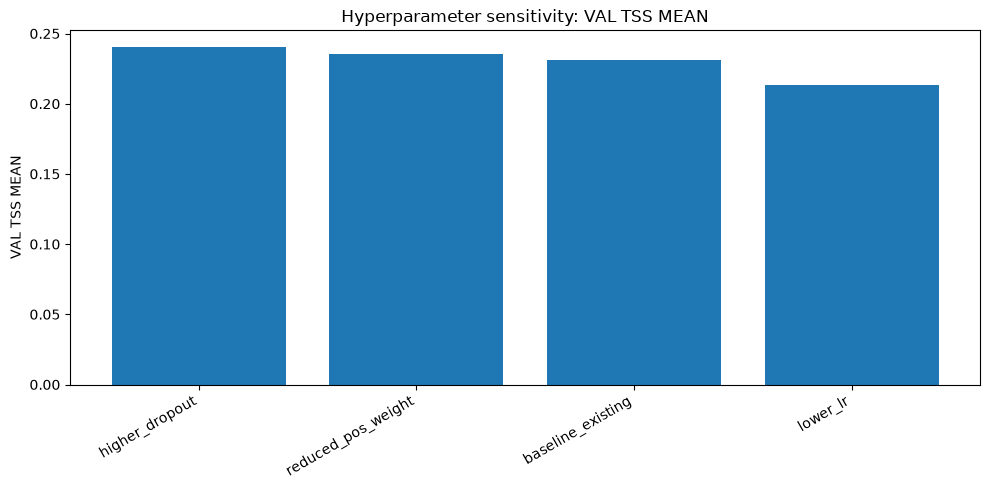

Saved results/figures/aia_resnet18_hp_sensitivity_val_tss_mean.png


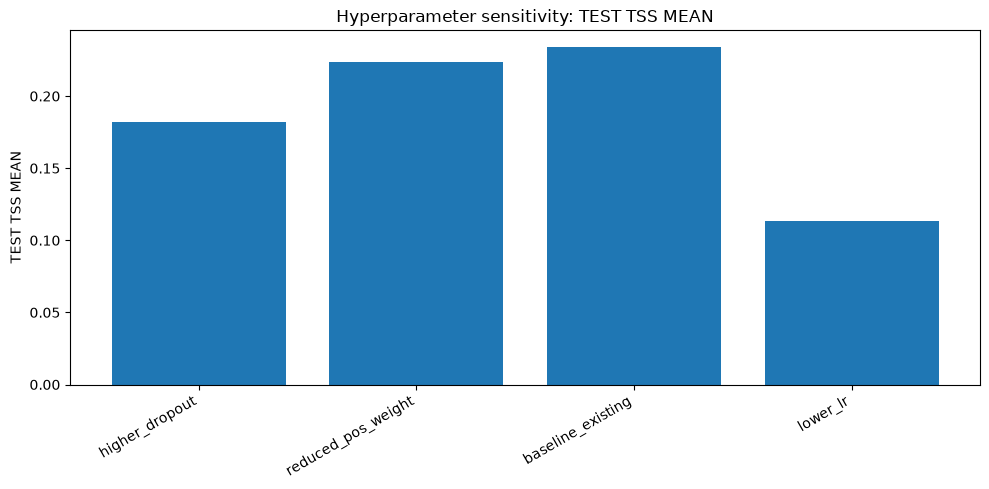

Saved results/figures/aia_resnet18_hp_sensitivity_test_tss_mean.png


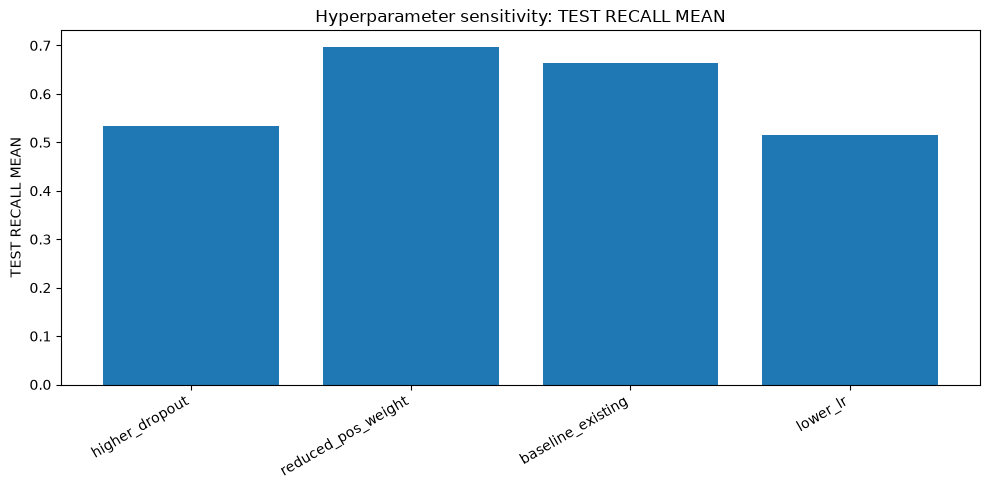

Saved results/figures/aia_resnet18_hp_sensitivity_test_recall_mean.png


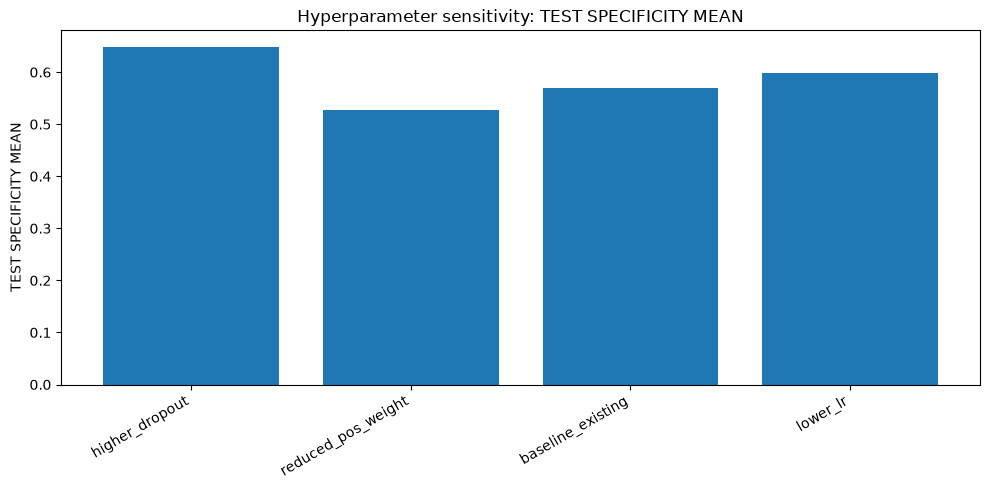

Saved results/figures/aia_resnet18_hp_sensitivity_test_specificity_mean.png


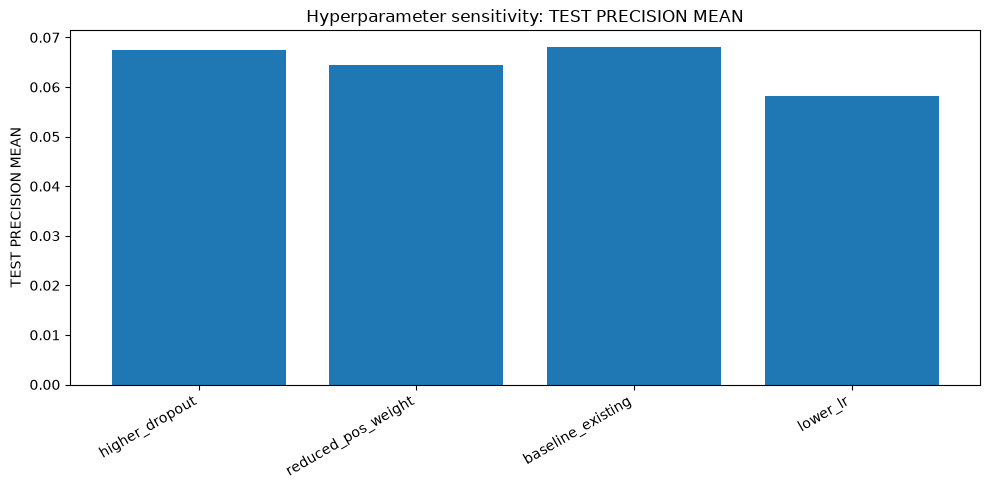

Saved results/figures/aia_resnet18_hp_sensitivity_test_precision_mean.png


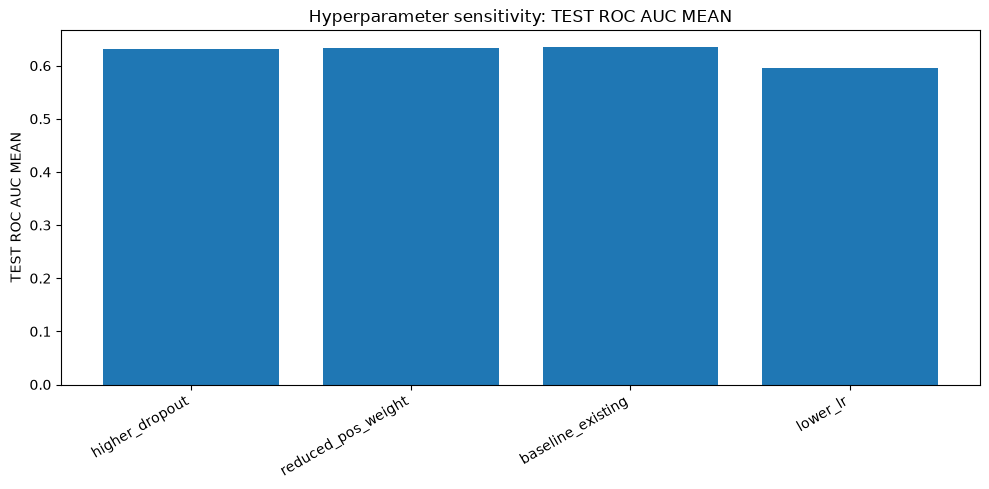

Saved results/figures/aia_resnet18_hp_sensitivity_test_roc_auc_mean.png


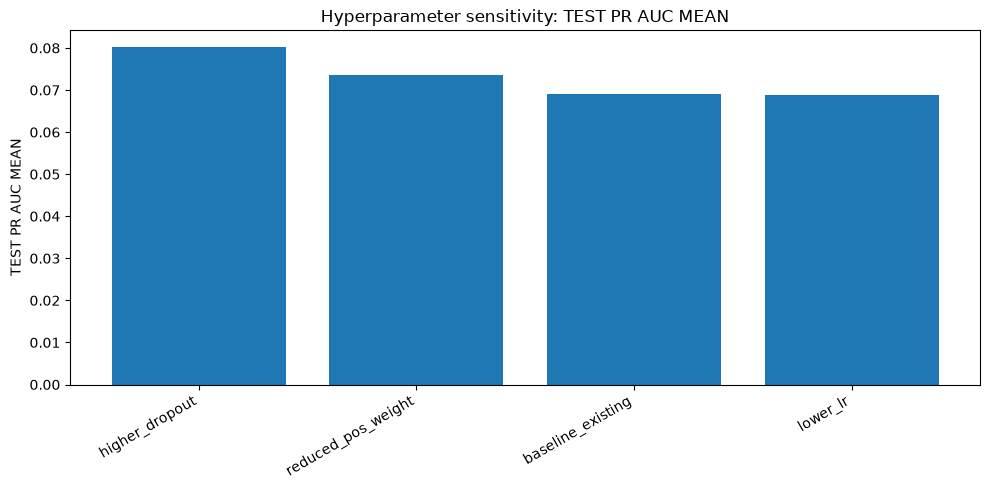

Saved results/figures/aia_resnet18_hp_sensitivity_test_pr_auc_mean.png


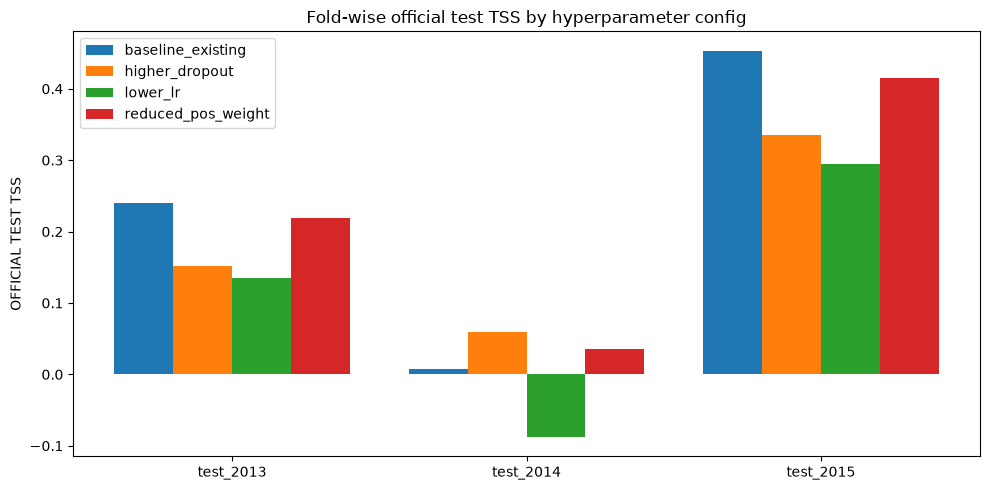

Saved results/figures/aia_resnet18_hp_sensitivity_foldwise_test_tss.png


In [12]:
import matplotlib.pyplot as plt

for metric in ["val_tss_mean", "test_tss_mean", "test_recall_mean", "test_specificity_mean", "test_precision_mean", "test_roc_auc_mean", "test_pr_auc_mean"]:
    labels = config_summary["config_name"].tolist()
    vals = pd.to_numeric(config_summary[metric], errors="coerce")
    plt.figure(figsize=(10, 5))
    plt.bar(labels, vals)
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric.replace("_", " ").upper())
    plt.title(f"Hyperparameter sensitivity: {metric.replace('_', ' ').upper()}")
    plt.tight_layout()
    fig_path = FIG_DIR / f"aia_resnet18_hp_sensitivity_{metric}.png"
    plt.savefig(fig_path, dpi=200)
    plt.show()
    print("Saved", fig_path.relative_to(ROOT))

pivot = all_df.pivot(index="fold_id", columns="config_name", values="test_tss").loc[[f["fold_id"] for f in FOLDS]]
plt.figure(figsize=(10, 5))
x = np.arange(len(pivot.index)); width = 0.8 / max(len(pivot.columns), 1)
for i, col in enumerate(pivot.columns):
    plt.bar(x + i * width, pivot[col].values, width=width, label=col)
plt.xticks(x + width * (len(pivot.columns)-1)/2, pivot.index)
plt.ylabel("OFFICIAL TEST TSS")
plt.title("Fold-wise official test TSS by hyperparameter config")
plt.legend()
plt.tight_layout()
fig_path = FIG_DIR / "aia_resnet18_hp_sensitivity_foldwise_test_tss.png"
plt.savefig(fig_path, dpi=200)
plt.show()
print("Saved", fig_path.relative_to(ROOT))

In [13]:
sel = config_summary.iloc[0]
baseline = config_summary[config_summary["config_name"] == "baseline_existing"]
baseline_text = ""
if len(baseline):
    b = baseline.iloc[0]
    baseline_text = f"The existing baseline achieved mean validation TSS={b['val_tss_mean']:.4f} and mean official test TSS={b['test_tss_mean']:.4f}. "

interpretation = f"""# Interpretation: ResNet18 Hyperparameter Sensitivity

This sensitivity study tested a small predefined set of physics-safe ResNet18 configurations across the usable chronological folds. Hyperparameter selection was based only on **mean validation TSS across folds**; test metrics were reported after selection and were not used to choose the configuration.

The validation-selected configuration was **{selected_config}**, with mean validation TSS={sel['val_tss_mean']:.4f} ± {sel['val_tss_std']:.4f}. Its official test performance was mean TSS={sel['test_tss_mean']:.4f} ± {sel['test_tss_std']:.4f}, mean Recall={sel['test_recall_mean']:.4f} ± {sel['test_recall_std']:.4f}, and mean ROC-AUC={sel['test_roc_auc_mean']:.4f} ± {sel['test_roc_auc_std']:.4f}.

{baseline_text}The results should be interpreted as a controlled sensitivity analysis rather than an open-ended search. If no configuration substantially stabilises the weak 2014 fold, this supports the conclusion that image-only AIA snapshots are sensitive to chronological/solar-cycle regime shift and motivates the next multimodal stage using AIA imagery plus SHARP magnetic temporal features.
"""
interp_path = METRICS_DIR / "aia_resnet18_hp_sensitivity_multifold_interpretation.md"
interp_path.write_text(interpretation)
display(Markdown(interpretation))
print("Saved", interp_path.relative_to(ROOT))

# Interpretation: ResNet18 Hyperparameter Sensitivity

This sensitivity study tested a small predefined set of physics-safe ResNet18 configurations across the usable chronological folds. Hyperparameter selection was based only on **mean validation TSS across folds**; test metrics were reported after selection and were not used to choose the configuration.

The validation-selected configuration was **higher_dropout**, with mean validation TSS=0.2403 ± 0.0219. Its official test performance was mean TSS=0.1819 ± 0.1409, mean Recall=0.5340 ± 0.2902, and mean ROC-AUC=0.6311 ± 0.0313.

The existing baseline achieved mean validation TSS=0.2315 and mean official test TSS=0.2339. The results should be interpreted as a controlled sensitivity analysis rather than an open-ended search. If no configuration substantially stabilises the weak 2014 fold, this supports the conclusion that image-only AIA snapshots are sensitive to chronological/solar-cycle regime shift and motivates the next multimodal stage using AIA imagery plus SHARP magnetic temporal features.


Saved results/metrics/aia_resnet18_hp_sensitivity_multifold_interpretation.md


## Backup and commit commands

After execution:

```bash
cd ~/solar_flare_aia

gcloud storage cp \
  results/metrics/aia_resnet18_hp_sensitivity_* \
  gs://suryabench-sharp-pipeline-bamidele/aia_cnn_baselines/resnet18_hp_sensitivity_multifold_physics_safe/

gcloud storage cp \
  results/figures/aia_resnet18_hp_sensitivity_*.png \
  gs://suryabench-sharp-pipeline-bamidele/aia_cnn_baselines/resnet18_hp_sensitivity_multifold_physics_safe/

gcloud storage cp \
  results/models/aia_resnet18_hp_sensitivity_*.pt \
  gs://suryabench-sharp-pipeline-bamidele/aia_cnn_baselines/resnet18_hp_sensitivity_multifold_physics_safe/

gcloud storage cp \
  notebooks/training/12_aia_resnet18_physics_safe_multifold_hyperparameter_sensitivity.ipynb \
  gs://suryabench-sharp-pipeline-bamidele/aia_cnn_baselines/resnet18_hp_sensitivity_multifold_physics_safe/

gcloud storage cp \
  notebooks/executed/12_aia_resnet18_physics_safe_multifold_hyperparameter_sensitivity_EXECUTED.ipynb \
  gs://suryabench-sharp-pipeline-bamidele/aia_cnn_baselines/resnet18_hp_sensitivity_multifold_physics_safe/

gcloud storage cp \
  logs/12_aia_resnet18_physics_safe_multifold_hyperparameter_sensitivity_run.log \
  gs://suryabench-sharp-pipeline-bamidele/aia_cnn_baselines/resnet18_hp_sensitivity_multifold_physics_safe/
```

Commit to GitHub, excluding model `.pt` files:

```bash
git add notebooks/training/12_aia_resnet18_physics_safe_multifold_hyperparameter_sensitivity.ipynb
git add notebooks/executed/12_aia_resnet18_physics_safe_multifold_hyperparameter_sensitivity_EXECUTED.ipynb
git add results/metrics/aia_resnet18_hp_sensitivity_*
git add results/figures/aia_resnet18_hp_sensitivity_*.png
git commit -m "Add physics-safe ResNet18 hyperparameter sensitivity study"
git push
```